# Evolving a Lunar Lander with differentiable Genetic Programming

## Installation
To install the required libraries run the command:

In [1]:
# !pip install -r requirements.txt

## Imports
Imports from the standard genepro-multi library are done here. Any adjustments (e.g. different operators) should be made in the notebook. For example:

```
class SmoothOperator(Node):
  def __init__(self):
    super(SmoothOperator,self).__init__()
    self.arity = 1
    self.symb = "SmoothOperator"

  def _get_args_repr(self, args):
    return self._get_typical_repr(args,'before')

  def get_output(self, X):
    c_outs = self._get_child_outputs(X)
    return np.smoothOperation(c_outs[0])

  def get_output_pt(self, X):
    c_outs = self._get_child_outputs_pt(X)
    return torch.smoothOperation(c_outs[0])
```

In [2]:
import gymnasium as gym

from genepro.node_impl import *
from genepro.evo import Evolution
from genepro.node_impl import Constant

import torch
import torch.optim as optim

import random
import os
import copy
from collections import namedtuple, deque

import matplotlib.pyplot as plt
from matplotlib import animation

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

## Reinforcement Learning Setup
Here we first setup the Gymnasium environment. Please see https://gymnasium.farama.org/environments/box2d/lunar_lander/ for more information on the environment. 

Then a memory buffer is made. This is a buffer in which state transitions are stored. When the buffer reaches its maximum capacity old transitions are replaced by new ones.

A frame buffer is initialised used to later store animation frames of the environment.

In [3]:
env = gym.make("LunarLander-v2", render_mode="rgb_array")

env.reset(seed=SEED)
env.action_space.seed(SEED)
env.observation_space.seed(SEED)

[42]

In [4]:
Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward'))

class ReplayMemory(object):
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

    def __iadd__(self, other):
      self.memory += other.memory
      return self 

    def __add__(self, other):
      self.memory = self.memory + other.memory 
      return self

In [5]:
frames = []

## Fitness Function

Here you get to be creative. The default setup evaluates 5 episodes of 300 frames. Think of what action to pick and what fitness function to use. The Multi-tree takes an input of $n \times d$ where $n$ is a batch of size 1.

In [6]:
# def fitness_function_pt(multitree, num_episodes=5, episode_duration=300, render=False, ignore_done=False):
#   memory = ReplayMemory(10000)
#   rewards = []

#   for ep in range(num_episodes):
#     # get initial state of the environment
#     observation = env.reset(seed=SEED + ep)
#     observation = observation[0]
    
#     for _ in range(episode_duration):
#       if render:
#         frames.append(env.render())

#       input_sample = torch.from_numpy(observation.reshape((1,-1))).float()

#       action = multitree.get_output_pt(input_sample).argmax(dim=1)
#       observation, reward, terminated, truncated, info = env.step(action.item())
#       rewards.append(reward)
#       output_sample = torch.from_numpy(observation.reshape((1,-1))).float()
#       memory.push(input_sample, torch.tensor([[action.item()]]), output_sample, torch.tensor([reward]))
#       if (terminated or truncated) and not ignore_done:
#         break

#   fitness = np.sum(rewards)
  
#   return fitness, memory


def _landing_error(observation):
  x, y, vx, vy, angle, angular_velocity, left_contact, right_contact = observation
  landing_phase = np.clip(1.0 - y / 1.2, 0.0, 1.0)

  return (
    1.8 * abs(x)
    + 0.25 * max(y, 0.0)
    + 0.6 * abs(vx)
    + landing_phase * (
      1.0 * abs(vy)
      + 1.4 * abs(angle)
      + 0.4 * abs(angular_velocity)
    )
  )


def _state_score(observation):
  x, y, vx, vy, angle, angular_velocity, left_contact, right_contact = observation
  landing_phase = np.clip(1.0 - y / 1.2, 0.0, 1.0)
  centered_bonus = max(0.0, 1.0 - abs(x))

  return (
    0.20 * centered_bonus
    - 0.08 * abs(x)
    - 0.04 * max(y, 0.0)
    - 0.06 * abs(vx)
    - landing_phase * (
      0.08 * abs(vy)
      + 0.16 * abs(angle)
      + 0.05 * abs(angular_velocity)
    )
  )


def _contact_bonus(observation):
  x, y, vx, vy, angle, angular_velocity, left_contact, right_contact = observation
  quality = np.exp(-3.0 * abs(x))

  if abs(vy) > 0.8:
    quality *= 0.5

  if abs(angle) > 0.4:
    quality *= 0.5

  return 45.0 * quality


def _is_stable_landing(observation):
  x, y, vx, vy, angle, angular_velocity, left_contact, right_contact = observation

  return (
    bool(left_contact)
    and bool(right_contact)
    and abs(x) < 0.25
    and abs(vx) < 0.25
    and abs(vy) < 0.35
    and abs(angle) < 0.20
    and abs(angular_velocity) < 0.50
  )


def fitness_function_pt(multitree, num_episodes=5, episode_duration=400, render=False, ignore_done=False):
  memory = ReplayMemory(10000)
  episode_scores = []

  for ep in range(num_episodes):
    # get initial state of the environment
    observation = env.reset(seed=SEED + ep)
    observation = observation[0]

    episode_score = 0.0
    prev_action = None
    prev_left_contact = bool(observation[6])
    prev_right_contact = bool(observation[7])
    prev_error = _landing_error(observation)
    
    for _ in range(episode_duration):
      if render:
        frames.append(env.render())

      input_sample = torch.from_numpy(observation.reshape((1,-1))).float()

      action = multitree.get_output_pt(input_sample).argmax(dim=1)
      action_idx = action.item()
      next_observation, reward, terminated, truncated, info = env.step(action_idx)

      x, y, vx, vy, angle, angular_velocity, left_contact, right_contact = next_observation
      left_contact = bool(left_contact)
      right_contact = bool(right_contact)

      error = _landing_error(next_observation)
      step_score = 4.0 * (prev_error - error) + _state_score(next_observation)
      prev_error = error

      # Prefer efficient, non-jittery trajectories without making thrust too expensive to discover.
      step_score -= 0.01

      if action_idx == 2:
        step_score -= 0.04
      elif action_idx in [1, 3]:
        step_score -= 0.01

      if prev_action in [1, 3] and action_idx in [1, 3] and prev_action != action_idx:
        step_score -= 0.03

      if left_contact and not prev_left_contact:
        step_score += _contact_bonus(next_observation)

      if right_contact and not prev_right_contact:
        step_score += _contact_bonus(next_observation)

      if terminated:
        if _is_stable_landing(next_observation):
          step_score += 350.0
        elif left_contact and right_contact:
          step_score += 120.0 - 60.0 * min(error, 3.0)
        elif left_contact or right_contact:
          step_score += 35.0 - 40.0 * min(error, 3.0)
        elif abs(x) > 1.0:
          step_score -= 160.0
        else:
          step_score -= 110.0

      episode_score += step_score
      prev_action = action_idx
      prev_left_contact = left_contact
      prev_right_contact = right_contact

      output_sample = torch.from_numpy(next_observation.reshape((1,-1))).float()
      memory.push(input_sample, torch.tensor([[action_idx]]), output_sample, torch.tensor([step_score]))
      observation = next_observation

      if (terminated or truncated) and not ignore_done:
        break

    tree_size_penalty = 0.002 * len(multitree)
    episode_scores.append(episode_score - tree_size_penalty)

  fitness = float(np.mean(episode_scores) - 0.35 * np.std(episode_scores))
  
  return fitness, memory



# def fitness_function_pt(multitree,
#                         num_episodes=5,
#                         episode_duration=300,
#                         render=False,
#                         ignore_done=False):

#     memory = ReplayMemory(10000)
#     episode_scores = []

#     for ep in range(num_episodes):
#         observation = env.reset(seed=SEED + ep)
#         observation = observation[0]

#         total_reward = 0.0
#         shaping_bonus = 0.0
#         fuel_penalty = 0.0

#         prev_action = None

#         for _ in range(episode_duration):
#             if render:
#                 frames.append(env.render())

#             input_sample = torch.from_numpy(
#                 observation.reshape((1,-1))
#             ).float()

#             action = multitree.get_output_pt(
#                 input_sample
#             ).argmax(dim=1).item()

#             next_observation, reward, terminated, truncated, info = env.step(action)

#             x, y, vx, vy, angle, angular_velocity, left_contact, right_contact = next_observation

#             # ---------------------------------------------------
#             # Light shaping only
#             # ---------------------------------------------------

#             # Encourage stable landing
#             shaping_bonus += (
#                 -0.03 * abs(x)
#                 -0.02 * abs(vx)
#                 -0.05 * abs(vy)
#                 -0.03 * abs(angle)
#             )

#             # Small reward for leg contact
#             if left_contact:
#                 shaping_bonus += 2

#             if right_contact:
#                 shaping_bonus += 2

#             # ---------------------------------------------------
#             # Small fuel penalty
#             # ---------------------------------------------------

#             if action == 2:
#                 fuel_penalty += 0.01

#             elif action in [1, 3]:
#                 fuel_penalty += 0.005

#             # ---------------------------------------------------
#             # Penalize unstable left-right switching
#             # ---------------------------------------------------

#             if prev_action in [1,3] and action in [1,3]:
#                 if prev_action != action:
#                     shaping_bonus -= 0.02

#             prev_action = action

#             # ---------------------------------------------------
#             # Big terminal rewards ONLY
#             # ---------------------------------------------------

#             # if terminated:
#             #     # Successful landing
#             #     if reward >= 100:
#             #         shaping_bonus += 100

#             #     # Heavy crash
#             #     elif reward <= -100:
#             #         shaping_bonus -= 50

#             total_reward += reward

#             output_sample = torch.from_numpy(
#                 next_observation.reshape((1,-1))
#             ).float()

#             memory.push(
#                 input_sample,
#                 torch.tensor([[action]]),
#                 output_sample,
#                 torch.tensor([reward])
#             )

#             observation = next_observation

#             if (terminated or truncated) and not ignore_done:
#                 break

#         tree_size_penalty = 0.01 * len(multitree)

#         final_score = (
#             total_reward
#             + shaping_bonus
#             - fuel_penalty
#             - tree_size_penalty
#         )

#         episode_scores.append(final_score)

#     fitness = float(np.mean(episode_scores))

#     return fitness, memory

## Evolution Setup
Here the leaf and internal nodes are defined. Think about the odds of sampling a constant in this default configurations. Also think about any operators that could be useful and add them here. 

Adjust the population size (multiple of 8 if you want to use the standard tournament selection), max generations and max tree size to taste. Be aware that each of these settings can increase the runtime.

In [7]:
num_features = env.observation_space.shape[0]
leaf_nodes = [Feature(i) for i in range(num_features)]
leaf_nodes = leaf_nodes + [Constant()] # Think about the probability of sampling a coefficient
internal_nodes = [Plus(),Minus(),Times(),Div()] #Add your own operators here

evo = Evolution(
  fitness_function_pt, internal_nodes, leaf_nodes,
  4,
  # pop_size=16,
  pop_size=32,
  # max_gens=10,
  max_gens=20,
  max_tree_size=31,
  n_jobs=8,
  verbose=True,
  seed=SEED)

## Evolve
Running this cell will use all the settings above as parameters

In [8]:
evo.evolve()

/mnt/c/Users/tboef/TU-Delft/Evolutionary-Algorithms/lunar_lander/.venv/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):
/mnt/c/Users/tboef/TU-Delft/Evolutionary-Algorithms/lunar_lander/.venv/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):
/mnt/c/Users/tboef/TU-Delft/Evolutionary-Algorithms/lunar_lander/.venv/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):
/mnt/c/Users/tboef/TU-Delft/Evolutionary-Algorithms/lunar_lander/.venv/lib/python3.10/site-packages/gymnasium/utils/passive_env_check

gen: 1,	best of gen fitness: -67.839,	best of gen size: 25
gen: 2,	best of gen fitness: 9.613,	best of gen size: 25
gen: 3,	best of gen fitness: 9.613,	best of gen size: 25
gen: 4,	best of gen fitness: 9.677,	best of gen size: 25
gen: 5,	best of gen fitness: 13.052,	best of gen size: 25
gen: 6,	best of gen fitness: 13.052,	best of gen size: 25
gen: 7,	best of gen fitness: 13.052,	best of gen size: 25
gen: 8,	best of gen fitness: 13.056,	best of gen size: 23
gen: 9,	best of gen fitness: 13.056,	best of gen size: 23
gen: 10,	best of gen fitness: 13.056,	best of gen size: 23
gen: 11,	best of gen fitness: 13.135,	best of gen size: 23
gen: 12,	best of gen fitness: 13.135,	best of gen size: 23
gen: 13,	best of gen fitness: 16.532,	best of gen size: 23
gen: 14,	best of gen fitness: 16.532,	best of gen size: 23
gen: 15,	best of gen fitness: 16.532,	best of gen size: 23
gen: 16,	best of gen fitness: 16.532,	best of gen size: 23
gen: 17,	best of gen fitness: 16.532,	best of gen size: 23
gen: 18,

# Test

In [13]:
def get_test_score(tree):
    rewards = []

    for i in range(10):
      # get initial state
      observation = env.reset(seed=i)
      observation = observation[0]

      for _ in range(500):    
        # build up the input sample for GP
        input_sample = torch.from_numpy(observation.reshape((1,-1))).float()
        # get output (squeezing because it is encapsulated in an array)
        output = tree.get_output_pt(input_sample)
        action = output.argmax(dim=1)
        observation, reward, terminated, truncated, info = env.step(action.item())
        rewards.append(reward)


        output_sample = torch.from_numpy(observation.reshape((1,-1))).float()
        if (terminated or truncated):
            break

    fitness = np.sum(rewards)
    
    return fitness

best = evo.best_of_gens[-1]

print(best.get_readable_repr())
print(get_test_score(best))

['((((x_6-x_0)/2.5909487536376576)-x_5)/((x_0/x_2)/(0.3295565340250192+((((x_6-x_0)/3.146759517969074)-x_5)-x_1))))', '(((x_0*(x_6+x_3))/((x_5/x_3)/x_2))*(x_2-((x_5/x_4)*(x_2+x_0))))', '((x_5-((x_5-x_0)/-4.524597644805908))+((((x_3-x_5)/(x_1/x_6))-x_5)/(x_1/x_6)))', '(((x_2/(x_4*x_2))+(x_4+(x_6*x_5)))-(x_4+(x_6*x_5)))']
-3550.1944197602343


## Make an animation
Here the best evolved individual is selected and one episode is rendered. Make sure to save your lunar landers over time to track progress and make comparisons.

MovieWriter imagemagick unavailable; using Pillow instead.


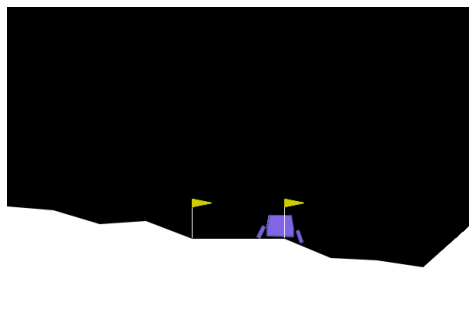

In [10]:
frames = []

# gist to save gif from https://gist.github.com/botforge/64cbb71780e6208172bbf03cd9293553
def save_frames_as_gif(frames, path='./', filename='evolved_lander.gif'):
  plt.figure(figsize=(frames[0].shape[1] / 72.0, frames[0].shape[0] / 72.0), dpi=72)
  patch = plt.imshow(frames[0])
  plt.axis('off')
  def animate(i):
      patch.set_data(frames[i])
  anim = animation.FuncAnimation(plt.gcf(), animate, frames = len(frames), interval=50)
  anim.save(path + filename, writer='imagemagick', fps=60)

frames = []
fitness_function_pt(best, num_episodes=1, episode_duration=500, render=True, ignore_done=False)
env.close()
save_frames_as_gif(frames)

## Play animation

<img src="evolved_lander.gif" width="750">

## Optimisation
The coefficients in the multi-tree aren't optimised. Here Q-learning (taken from https://pytorch.org/tutorials/intermediate/reinforcement_q_learning.html) is used to optimise the weights further. Incorporate coefficient optimisation in training your agent(s). Coefficient Optimisation can be expensive. Think about how often you want to optimise, when, which individuals etc.

In [11]:
batch_size = 128
GAMMA = 0.99

constants = best.get_subtrees_consts()

if len(constants)>0:
  optimizer = optim.AdamW(constants, lr=1e-3, amsgrad=True)

for _ in range(500):

  if len(constants)>0 and len(evo.memory)>batch_size:
    target_tree = copy.deepcopy(best)

    transitions = evo.memory.sample(batch_size)
    batch = Transition(*zip(*transitions))
    
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                        batch.next_state)), dtype=torch.bool)

    non_final_next_states = torch.cat([s for s in batch.next_state
                                               if s is not None])
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    state_action_values = best.get_output_pt(state_batch).gather(1, action_batch)
    next_state_values = torch.zeros(batch_size, dtype=torch.float)
    with torch.no_grad():
      next_state_values[non_final_mask] = target_tree.get_output_pt(non_final_next_states).max(1)[0].float()

    expected_state_action_values = (next_state_values * GAMMA) + reward_batch
    
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))
   
    # Optimize the model
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_value_(constants, 100)
    optimizer.step()

print(best.get_readable_repr())
print(get_test_score(best))

['((((x_6-x_0)/2.5909487536376576)-x_5)/((x_0/x_2)/(0.3295565340250192+((((x_6-x_0)/3.146759517969074)-x_5)-x_1))))', '(((x_0*(x_6+x_3))/((x_5/x_3)/x_2))*(x_2-((x_5/x_4)*(x_2+x_0))))', '((x_5-((x_5-x_0)/-4.524597644805908))+((((x_3-x_5)/(x_1/x_6))-x_5)/(x_1/x_6)))', '(((x_2/(x_4*x_2))+(x_4+(x_6*x_5)))-(x_4+(x_6*x_5)))']
-3550.1944197602343


MovieWriter imagemagick unavailable; using Pillow instead.


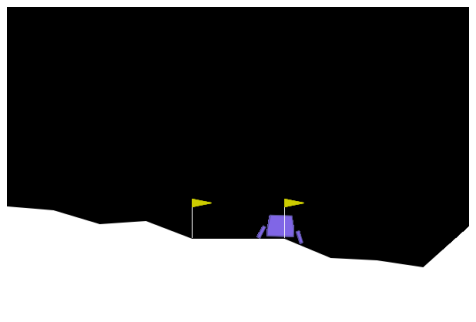

In [12]:
frames = []
fitness_function_pt(best, num_episodes=1, episode_duration=500, render=True, ignore_done=False)
env.close()
save_frames_as_gif(frames, filename='evolved_lander_RL.gif')

<img src="evolved_lander_RL.gif" width="750">